NIH Xray Image Classification Project

Data Pipeline creation

In [120]:
import pandas as pd
import torch
from torch.utils.data import Dataset, Subset, DataLoader, random_split
from torch import nn
from torch import optim
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
import os
import glob
import helper_utils
import time

In [121]:
print(dir(helper_utils))

['Helper', 'Pickle', 'SpeedPerformance', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'helper', 'read_excel', 'timer']


Exploring Dataset

In [122]:
path_dataset = r'D:\Python learn\Projects\NIH Chest Xray Classifier\NIH_Xray'




In [123]:
from directory_tree import DisplayTree
def print_datafolder_str(root_dir, max_depth =1):
    config_tree = {
        "dirPath" : root_dir,
        "onlyDirs" : False,
        "maxDepth" : max_depth,
        "sortBy" : 1,
    }
    DisplayTree(**config_tree)

In [124]:
print_datafolder_str(path_dataset, max_depth=1)

NIH_Xray/
├── ARXIV_V5_CHESTXRAY.pdf
├── BBox_List_2017.csv
├── Data_Entry_2017.csv
├── FAQ_CHESTXRAY.pdf
├── LOG_CHESTXRAY.pdf
├── README_CHESTXRAY.pdf
├── test_list.txt
├── train_val_list.txt
├── images_001/
├── images_002/
├── images_003/
├── images_004/
├── images_005/
├── images_006/
├── images_007/
├── images_008/
├── images_009/
├── images_010/
├── images_011/
└── images_012/


In [125]:
df_labels = pd.read_csv(f'{path_dataset}/Data_Entry_2017.csv')

In [126]:
df_labels.head(100000)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,00026487_000.png,No Finding,0,26487,9,F,PA,2114,2991,0.143,0.143,NaN
99996,00026488_000.png,No Finding,0,26488,43,F,PA,2992,2991,0.143,0.143,NaN
99997,00026489_000.png,No Finding,0,26489,59,M,PA,3056,2544,0.139,0.139,NaN
99998,00026489_001.png,Infiltration,1,26489,59,M,PA,2832,2901,0.143,0.143,NaN


In [127]:
df_labels['Finding Labels'].unique()

<StringArray>
[                                                  'Cardiomegaly',
                                         'Cardiomegaly|Emphysema',
                                          'Cardiomegaly|Effusion',
                                                     'No Finding',
                                                         'Hernia',
                                            'Hernia|Infiltration',
                                                    'Mass|Nodule',
                                                   'Infiltration',
                                          'Effusion|Infiltration',
                                                         'Nodule',
 ...
                                      'Infiltration|Cardiomegaly',
                  'Cardiomegaly|Consolidation|Effusion|Pneumonia',
  'Emphysema|Infiltration|Nodule|Pleural_Thickening|Pneumothorax',
             'Atelectasis|Nodule|Pleural_Thickening|Pneumothorax',
                                 'Consolida

In [128]:
df_labels['Finding Labels'].isna().sum()

np.int64(0)

**Lets split the target column into multiples as we have 

In [129]:
data = df_labels.copy()


In [130]:
from itertools import chain
import numpy as np

In [131]:
(data['Finding Labels'] != data['Finding Labels'].str.strip()).sum()

np.int64(0)

In [132]:
#Find if there any spaces around '|' to avoid duplication of a class
df_labels['Finding Labels'].str.contains(r'\s+\|\s+|\s+\||\|\s+', regex=True).sum()

np.int64(0)

In [133]:
#Use Pandas dummies and function to split the label column and conctat those columns
labels_dummies = data['Finding Labels'].str.get_dummies(sep = '|')
data = pd.concat([data,labels_dummies], axis = 1 )

In [134]:
labels_dummies.head()

,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [135]:
from collections import Counter
import pandas as pd

label_counter = Counter()

for labels in df_labels['Finding Labels']:
    if pd.isna(labels) or labels.strip() == '':
        continue
    for label in labels.split('|'):
        label = label.strip()
        if label:
            label_counter[label] += 1

class_counts_df = pd.DataFrame(
    sorted(label_counter.items(), key=lambda x: x[1], reverse=True),
    columns=['Class', 'Count']
)

print(class_counts_df)

                 Class  Count
0           No Finding  60361
1         Infiltration  19894
2             Effusion  13317
3          Atelectasis  11559
4               Nodule   6331
5                 Mass   5782
6         Pneumothorax   5302
7        Consolidation   4667
8   Pleural_Thickening   3385
9         Cardiomegaly   2776
10           Emphysema   2516
11               Edema   2303
12            Fibrosis   1686
13           Pneumonia   1431
14              Hernia    227


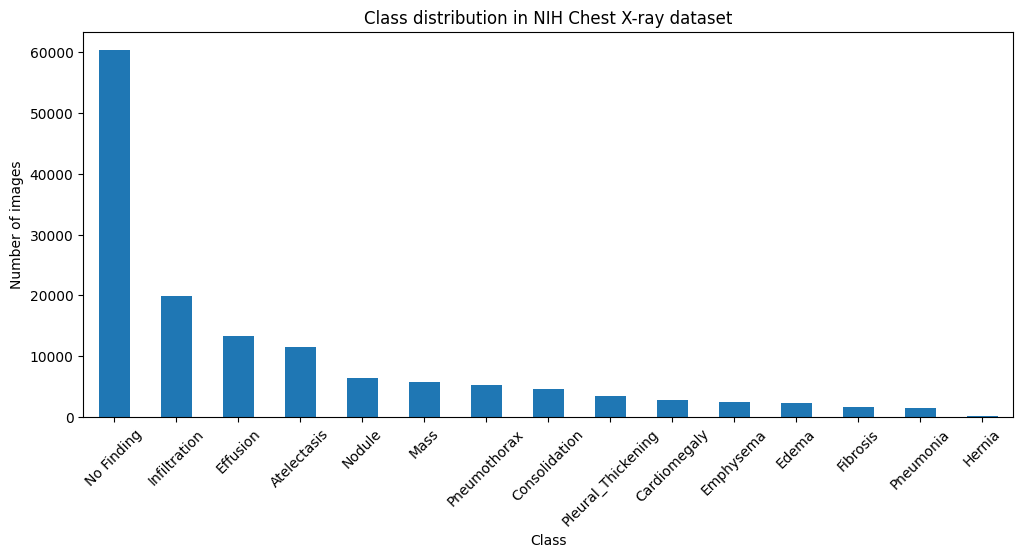

In [136]:
import matplotlib.pyplot as plt

class_counts_df.plot(x='Class', y='Count', kind='bar', figsize=(12, 5), legend=False)
plt.ylabel("Number of images")
plt.title("Class distribution in NIH Chest X-ray dataset")
plt.xticks(rotation=45)
plt.show()

**As there is big imbalance in dataset we need to make sure we are addressing this imbalance otherwise our model will fail to train classes with less training examples.**

In [137]:

class NIHDataset(Dataset):
    def __init__(self, root_dir, csv_file="Data_Entry_2017.csv", transform=None):
        # save inputs
        self.root_dir = root_dir
        self.transform = transform

        # load metadata csv
        csv_path = os.path.join(root_dir, csv_file)
        self.data = pd.read_csv(csv_path)

        # make sure Finding Labels has no NaN
        self.data["Finding Labels"] = self.data["Finding Labels"].fillna("")



        # create full list of unique classes
        self.all_labels = sorted(
            set(
                self.data["Finding Labels"]
                .str.split("|")
                .explode()
                .str.strip()
            ) - {""}
        )

        # map label name -> index
        self.class_to_idx = {label: idx for idx, label in enumerate(self.all_labels)}
        self.idx_to_class = {idx: label for label, idx in self.class_to_idx.items()}

        # scan all image folders and create lookup: image_name -> full_path
        self.image_paths = {}
        image_folders = sorted(glob.glob(os.path.join(root_dir, "images_*")))

        for folder in image_folders:
            pngs = glob.glob(os.path.join(folder, "**", "*.png"), recursive=True)
            for img_path in pngs:
                image_name = os.path.basename(img_path)
                self.image_paths[image_name] = img_path

        # keep only rows whose image file actually exists
        self.data = self.data[self.data["Image Index"].isin(self.image_paths.keys())].reset_index(drop=True)

    def __len__(self):
        # total number of samples
        return len(self.data)

    def __getitem__(self, idx):
        # get one row
        row = self.data.iloc[idx]

        # image name and path
        image_name = row["Image Index"]
        image_path = self.image_paths[image_name]

        # load image
        image = Image.open(image_path).convert("RGB")

        # create empty multi-label target vector
        target = torch.zeros(len(self.all_labels), dtype=torch.float32)

        # fill target vector based on Finding Labels
        labels = row["Finding Labels"]
        if labels != "":
            for label in labels.split("|"):
                label = label.strip()
                if label in self.class_to_idx:
                    target[self.class_to_idx[label]] = 1.0

        # apply transforms
        if self.transform:
            image = self.transform(image)

        return image, target

Why convert images to "RGB"???

Why this helps:

- Pretrained models usually expect 3 channels
- Models like DenseNet, ResNet, EfficientNet are generally trained on ImageNet, where images are RGB.
- Our code will use view(3, -1)
- That only works if the image has 3 channels.
- It avoids shape errors -- If one image is grayscale and another is RGB, batching becomes messy.

In [138]:
NIH_dataset = NIHDataset(root_dir=path_dataset,csv_file="Data_Entry_2017.csv", transform=None)

In [139]:
print(f'Length of the dataset: {len(NIH_dataset)}')

Length of the dataset: 112120


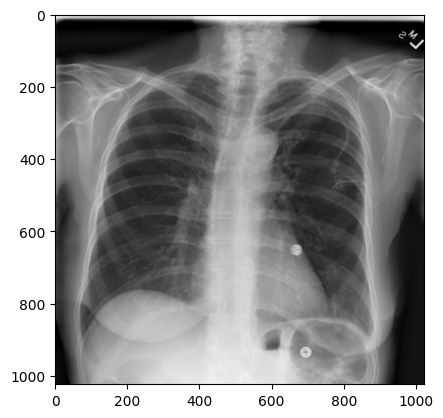

Description: ['Effusion', 'Infiltration']
Image shape: (1024, 1024)



In [140]:
# Look at a sample to check it's working correctly
sel_idx = 20
img, label = NIH_dataset[sel_idx]

# Visualize the image

plt.imshow(img)
plt.show()

# Print its description
label_names = [NIH_dataset.idx_to_class[i] for i, v in enumerate(label) if v == 1]
print(f'Description: {label_names}')

# Print its shape
print(f'Image shape: {img.size}\n')  # PIL image size is (width, height)

**Flow of Data preprocessing**
- Take out Empty row values.#done
- Split the cell with '|' and create multiclass for each training example if applicable.
- Find if there is any imbalance and correct if required.
- Create a unique class name file .txt.
- 


In [141]:
img,lable = NIH_dataset[sel_idx]
print(img.mode)

RGB


In [142]:
mean = torch.tensor([0.4981, 0.4981, 0.4981])
std = torch.tensor([0.2482, 0.2482, 0.2482])

Lets Perform Transformation:
For augmentation make sure to use rotation angle to be small since higher rotation angle is not a very common in xrays and can mislead the model. Also strictly avoid flipping

Its better to test augmentation and see if it is making any unrealstic augmentation before we feed it in training.

In [143]:
# pick one sample from your dataset
img, label = NIH_dataset[0]   # img is likely a PIL image

# define test augmentations
rotation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=3)
])

affine_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomAffine(
        degrees=1,
        translate=(0.002, 0.002),
        #scale=(0.98, 1.02)
    )
])

# helper function to show augmented samples
def show_augmentations(original_img, transform, title, n=5):
    plt.figure(figsize=(15, 3))

    # show original
    plt.subplot(1, n + 1, 1)
    plt.imshow(original_img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # show augmented versions
    for i in range(n):
        aug_img = transform(original_img)
        plt.subplot(1, n + 1, i + 2)
        plt.imshow(aug_img, cmap="gray")
        plt.title(f"{title} {i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

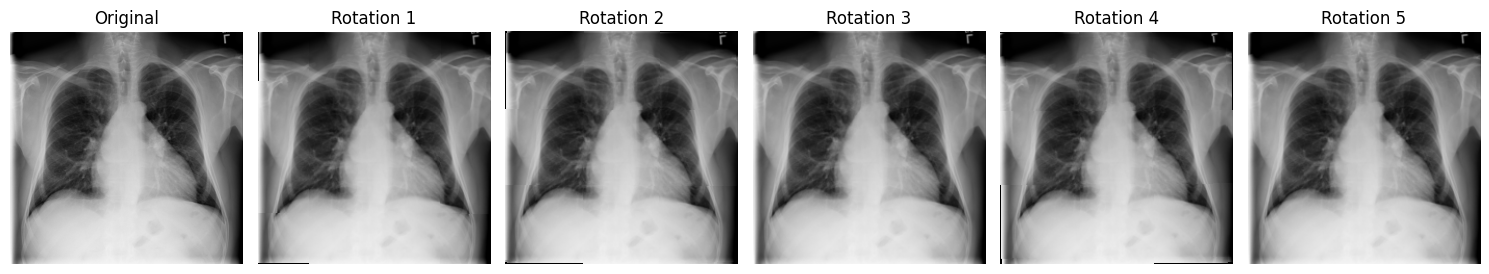

In [144]:
show_augmentations(img, affine_transform, "Rotation")

In [145]:
def transformation(mean, std):

    main_transform = [
        transforms.Resize((244,244)),
        transforms.ToTensor(),
        transforms.Normalize(mean = mean, std = std),
    ]

    augment_transform = [
        transforms.RandomAffine(
            degrees = 1,
            translate=(0.002, 0.002),
            #scale=(0.98, 1.02) skipped for uncommon augmentation of image which might cause mislead the model and also heavy on CPU
        )
    ]

    resize_transform = transforms.Compose(main_transform)
    aug_resize_transform = transforms.Compose(main_transform + augment_transform)

    return resize_transform, aug_resize_transform




In [146]:
resize_transform, aug_resize_transform = transformation(mean, std)

print(resize_transform)
print(aug_resize_transform)

Compose(
    Resize(size=(244, 244), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=tensor([0.4981, 0.4981, 0.4981]), std=tensor([0.2482, 0.2482, 0.2482]))
)
Compose(
    Resize(size=(244, 244), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=tensor([0.4981, 0.4981, 0.4981]), std=tensor([0.2482, 0.2482, 0.2482]))
    RandomAffine(degrees=[-1.0, 1.0], translate=(0.002, 0.002))
)


We need to create a class to make sure after random_split we are able to assign appropirate transformation to subset of a data

In [147]:
class SubsetwithTransform(Dataset):

    def __init__(self,subset:Subset, transform = None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self,idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image,label



In [148]:
def get_dataloaders(
        dataset,
        batch_size,
        val_fraction,
        test_fraction,
        resize_transform,
        aug_resize_transform,
        num_workers
        

):
    total_size = len(dataset)
    val_size = int(total_size * val_fraction)
    test_size = int(total_size * test_fraction)
    train_size = (total_size -  val_size - test_size)

    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size ]
    )

    train_dataset = SubsetwithTransform(train_dataset,aug_resize_transform)
    val_dataset = SubsetwithTransform(val_dataset,resize_transform)
    test_dataset = SubsetwithTransform(test_dataset,resize_transform)


    train_loader = DataLoader(train_dataset, batch_size= batch_size,num_workers= num_workers, pin_memory= True,  shuffle = True)
    val_loader = DataLoader(val_dataset, batch_size= batch_size, shuffle = False)
    test_loader = DataLoader(test_dataset, batch_size= batch_size, shuffle = False)

    return train_loader , val_loader, test_loader
    

    

In [149]:
train_loader, val_loader, test_loader = get_dataloaders(
    dataset=NIH_dataset,
    batch_size=64,
    val_fraction=0.15,
    test_fraction=0.2,
    resize_transform=resize_transform,
    aug_resize_transform=aug_resize_transform,
    num_workers=0,
    
    
)

In [150]:
print('=== Train Loader ===')
print(f"Number of batches in train_loader: {len(train_loader)}")
train_dataset = train_loader.dataset
print(f"Number of samples in train_dataset: {len(train_dataset)}")
print(f"Transforms applied to train_dataset: {train_dataset.transform}")
print(f"train_dataset type: {type(train_dataset)}")

print('\n=== Test Loader ===')
print(f"Number of batches in test_loader: {len(test_loader)}")
test_dataset = test_loader.dataset
print(f"Number of samples in test_dataset: {len(test_dataset)}")
print(f"Transforms applied to test_dataset: {test_dataset.transform}")
print(f"test_dataset type: {type(test_dataset)}")

=== Train Loader ===
Number of batches in train_loader: 1139
Number of samples in train_dataset: 72878
Transforms applied to train_dataset: Compose(
    Resize(size=(244, 244), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=tensor([0.4981, 0.4981, 0.4981]), std=tensor([0.2482, 0.2482, 0.2482]))
    RandomAffine(degrees=[-1.0, 1.0], translate=(0.002, 0.002))
)
train_dataset type: <class '__main__.SubsetwithTransform'>

=== Test Loader ===
Number of batches in test_loader: 351
Number of samples in test_dataset: 22424
Transforms applied to test_dataset: Compose(
    Resize(size=(244, 244), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=tensor([0.4981, 0.4981, 0.4981]), std=tensor([0.2482, 0.2482, 0.2482]))
)
test_dataset type: <class '__main__.SubsetwithTransform'>


Make a Note of Mean and Std for other model variation such as manually created net and DenseNet for experimentation.
 Mean: tensor([0.4981, 0.4981, 0.4981])

 Standard Deviation: tensor([0.2482, 0.2482, 0.2482])

In [151]:
num_classes = len(NIH_dataset.all_labels)
print(num_classes)

15


We will use dense hence we need to setup a model function for it as dense net has already model and layers setup.
We will also need to make sure we are equating output classes with number of classes we have in our dataset

In [152]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [153]:
def compute_pos_weight(dataset):
    """
    Compute per-class pos_weight for BCEWithLogitsLoss.
    Assumes dataset.data['Finding Labels'] exists and dataset.all_labels exists.
    """
    num_classes = len(dataset.all_labels)
    class_counts = torch.zeros(num_classes, dtype=torch.float32)

    for labels in dataset.data["Finding Labels"].fillna(""):
        label_list = [label.strip() for label in labels.split("|") if label.strip()]
        for label in label_list:
            class_idx = dataset.class_to_idx[label]
            class_counts[class_idx] += 1

    total_samples = len(dataset)
    neg_counts = total_samples - class_counts

    pos_weight = neg_counts / class_counts
    return pos_weight

In [154]:
pos_weight = compute_pos_weight(NIH_dataset)
print(pos_weight)

tensor([  8.6998,  39.3890,  23.0240,  47.6843,   7.4193,  43.5628,  65.5006,
        492.9207,   4.6359,  18.3912,   0.8575,  16.7097,  32.1226,  77.3508,
         20.1467])


In [155]:
from torchvision.models import densenet121, DenseNet121_Weights


class NIHDenseNet121(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(NIHDenseNet121, self).__init__()

        if pretrained:
            weights = DenseNet121_Weights.DEFAULT
            self.model = densenet121(weights=weights)
        else:
            self.model = densenet121(weights=None)

        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.model(x)
        return x


def initialize_nih_densenetmodel(num_classes, pos_weight, lr=0.0001, pretrained=True):
    torch.manual_seed(42)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = NIHDenseNet121(num_classes=num_classes, pretrained=pretrained)
    model = model.to(device)

    loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    optimizer = optim.Adam(model.parameters(), lr=lr)

    return model, loss_function, optimizer, device

In [ ]:
#Train the Model
def train_epoch(model, loss_function, optimizer,train_loader, device):
    model = model.to(device)
    model.train()
    epoch_loss = 0.0
    running_loss = 0.0
    num_correct_pred = 0
    total_pred = 0
    total_batches = len(train_loader)
    epoch_start_time = time.time()

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        batch_start_time = time.time()
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        optimizer.step()

        batch_time = time.time() - batch_start_time
        elapsed_epoch_time = time.time() - epoch_start_time

        loss_value = loss.item()
        epoch_loss += loss_value
        running_loss += loss_value
        
        probs = torch.sigmoid(outputs)
        predicted_values = (probs > 0.5).float()
        batch_size = targets.numel()
        total_pred += batch_size
        num_correct_pred += (predicted_values == targets).sum().item()

        divider = 64

        if (batch_idx+1)%divider == 0 or (batch_idx+1) == total_batches:
            avg_running_loss = running_loss/divider
            accuracy = (num_correct_pred/total_pred)*100
            avg_time_per_batch = elapsed_epoch_time / (batch_idx + 1)
            print(f'\tStep {(batch_idx+1)}/{total_batches} - Loss: {avg_running_loss:.3f} | Acc: {accuracy:.2f}% | Time Elapsed: {elapsed_epoch_time/60:.2f}Mins | Avg Time Per Image: {avg_time_per_batch:.2f}Secs')
            #reset
            running_loss = 0.0
            num_correct_pred = 0
            total_pred = 0

    avg_epoch_loss = epoch_loss/total_batches
    return model, avg_epoch_loss

In [157]:
def evaluate(model, val_loader):
    model.eval()
    num_correct_pred = 0
    total_predictions = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            predicted_values = (probs > 0.5).float()
            batch_size = targets.numel()
            total_predictions += batch_size
            num_correct_pred += (predicted_values == targets).sum().item()

    accuracy = (num_correct_pred/total_predictions)*100
    print(f'\tValidation Accuracy: {accuracy:.2f}%')
    return accuracy

In [158]:
model, loss_function, optimizer, device = initialize_nih_densenetmodel(
    num_classes=num_classes,
    pos_weight=pos_weight,
    lr=1e-4,
    pretrained=True
)

In [159]:
num_epochs = 2
train_loss = []
test_acc = []

for epoch in range(num_epochs):
    print(f'[Training] Epoch {epoch+1}:')
    trained_model,loss = train_epoch(model, loss_function, optimizer,train_loader, device)
    train_loss.append(loss)


    print(f'[Validation] Epoch {epoch+1}:')
    accuracy = evaluate(model, val_loader)
    test_acc.append(accuracy)

[Training] Epoch 1:
	Step 64/1139 - Loss: 1.234 | Acc: 59.98% | Time Elapsed: 87.96Secs | Avg Time Per Batch: 1.37Secs
	Step 128/1139 - Loss: 1.169 | Acc: 61.74% | Time Elapsed: 179.53Secs | Avg Time Per Batch: 1.40Secs
	Step 192/1139 - Loss: 1.078 | Acc: 64.64% | Time Elapsed: 270.84Secs | Avg Time Per Batch: 1.41Secs
	Step 256/1139 - Loss: 1.024 | Acc: 67.52% | Time Elapsed: 364.17Secs | Avg Time Per Batch: 1.42Secs
	Step 320/1139 - Loss: 1.015 | Acc: 69.82% | Time Elapsed: 457.36Secs | Avg Time Per Batch: 1.43Secs
	Step 384/1139 - Loss: 0.998 | Acc: 70.61% | Time Elapsed: 551.99Secs | Avg Time Per Batch: 1.44Secs
	Step 448/1139 - Loss: 1.001 | Acc: 71.08% | Time Elapsed: 642.27Secs | Avg Time Per Batch: 1.43Secs
	Step 512/1139 - Loss: 1.053 | Acc: 70.20% | Time Elapsed: 732.40Secs | Avg Time Per Batch: 1.43Secs
	Step 576/1139 - Loss: 1.023 | Acc: 69.87% | Time Elapsed: 822.97Secs | Avg Time Per Batch: 1.43Secs
	Step 640/1139 - Loss: 1.038 | Acc: 69.38% | Time Elapsed: 917.52Secs | A